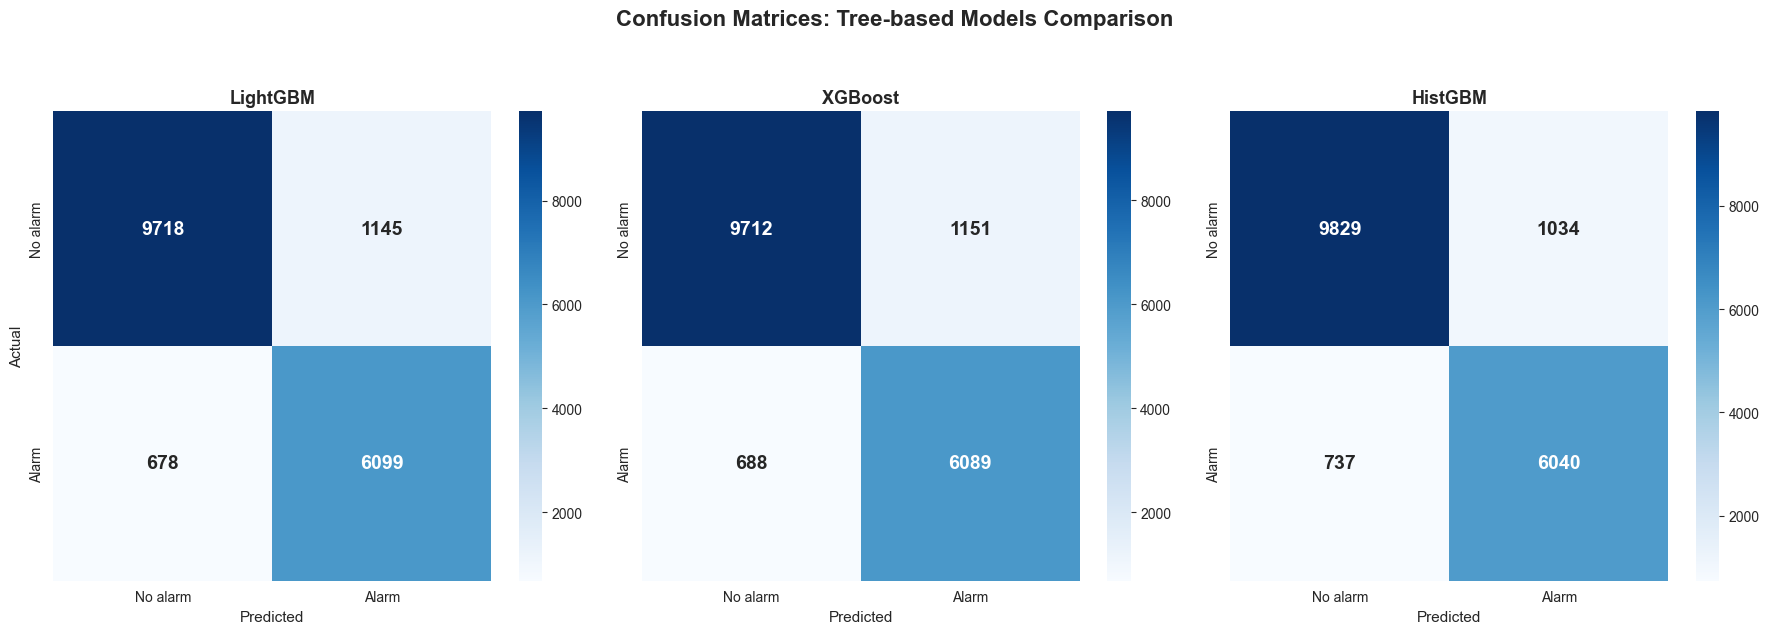

          Accuracy  Precision  Recall     F1
Model                                       
LightGBM     0.897      0.842   0.900  0.870
XGBoost      0.896      0.841   0.898  0.869
HistGBM      0.900      0.854   0.891  0.872


In [6]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (confusion_matrix, accuracy_score, f1_score, recall_score, precision_score)
X_test = pd.read_csv('../data/processed/X_test.csv')
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

models_to_load = {'LightGBM': '../models/4__lightgbm__v1.pkl',
                  'XGBoost': '../models/4__xgboost__v1.pkl',
                  'HistGBM': '../models/4__histgbm__v1.pkl' }
models = {}
for name, path in models_to_load.items():
    with open(path, 'rb') as f:
        models[name] = pickle.load(f)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
metrics_rows = []
for ax, (name, model) in zip(axes, models.items()):
    thresholds = {'LightGBM': 0.612, 'XGBoost': 0.608, 'HistGBM': 0.663}
for ax, (name, model) in zip(axes, models.items()):
    y_score = model.predict_proba(X_test)[:, 1]
    thr = thresholds[name]
    y_pred = (y_score >= thr).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No alarm', 'Alarm'],
                yticklabels=['No alarm', 'Alarm'],
                annot_kws={'size': 14, 'weight': 'bold'})
    ax.set_title(name, fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=11)
    if ax == axes[0]:
        ax.set_ylabel('Actual', fontsize=11)
    metrics_rows.append({'Model': name, 'Accuracy':  accuracy_score(y_test, y_pred),
                         'Precision': precision_score(y_test, y_pred, zero_division=0),
                         'Recall': recall_score(y_test, y_pred, zero_division=0),
                         'F1': f1_score(y_test, y_pred, zero_division=0) })
plt.suptitle('Confusion Matrices: Tree-based Models Comparison', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()
metrics_df = pd.DataFrame(metrics_rows).set_index('Model').round(3)
print(metrics_df)



# Confusion Matrices Conclusion
These charts show how many predictions were right or wrong.
* **LightGBM** is the best at catching actual alarms, since it has the fewest missed alarms.
* **HistGBM** is the best at avoiding false alarms, since it has the highest number of correct "No alarm" predictions.
## Metrics
* **HistGBM** is the overall winner in **Accuracy (0.900)**, **Precision (0.854)**, and **F1 Score (0.872)**. It is the most balanced and reliable model among the three.
* **LightGBM** has the highest **Recall (0.900)**, meaning it is the most sensitive model for detecting the alarm.
* **XGBoost** performs very similarly to LightGBM but slightly trails behind in almost every metric.
# Why LightGBM model is the best choice
While **HistGBM** has higher overall accuracy, **LightGBM** is the best model for safety-critical applications. It achieves the highest **Recall (0.900)**, meaning it is the most effective at identifying actual threats. In our opinion, missing an alarm is far more dangerous than a false alarm. LightGBM missed only **678** alarms, which is significantly better than HistGBM's **737** misses. We accept a slightly higher rate of false alarms to ensure that the maximum number of people are warned in time. Every missed alarm represents a potential risk to life, making Recall one of the most critical metrics. **LightGBM** is the optimal choice because it minimizes the risk of failure when it matters most.


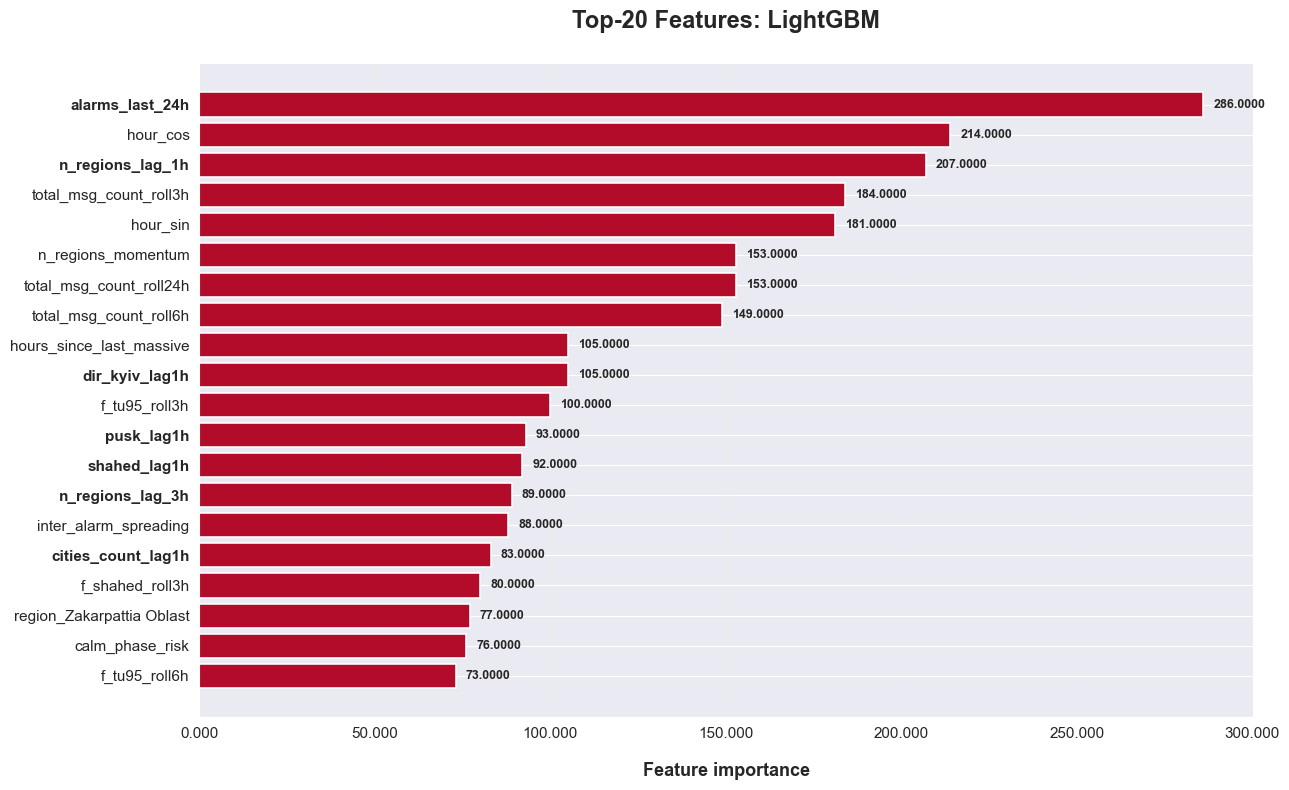

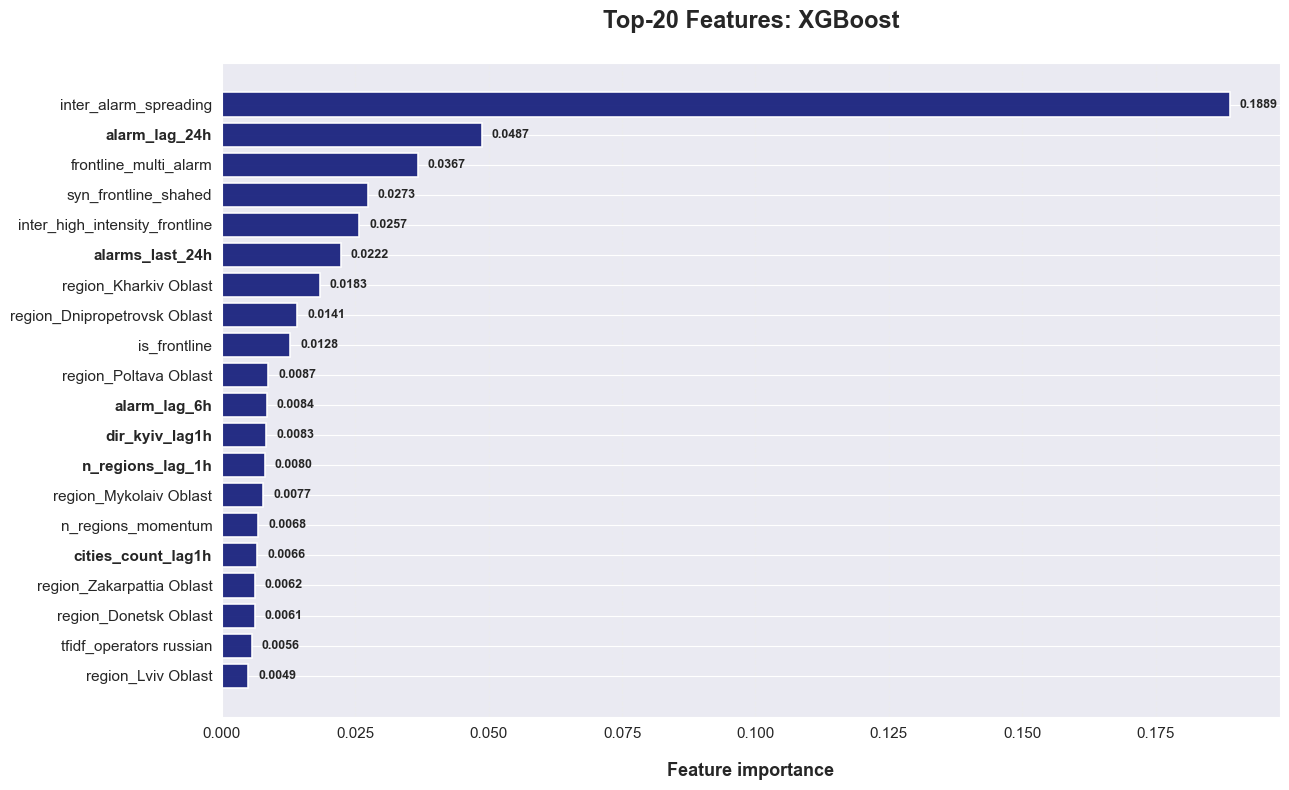

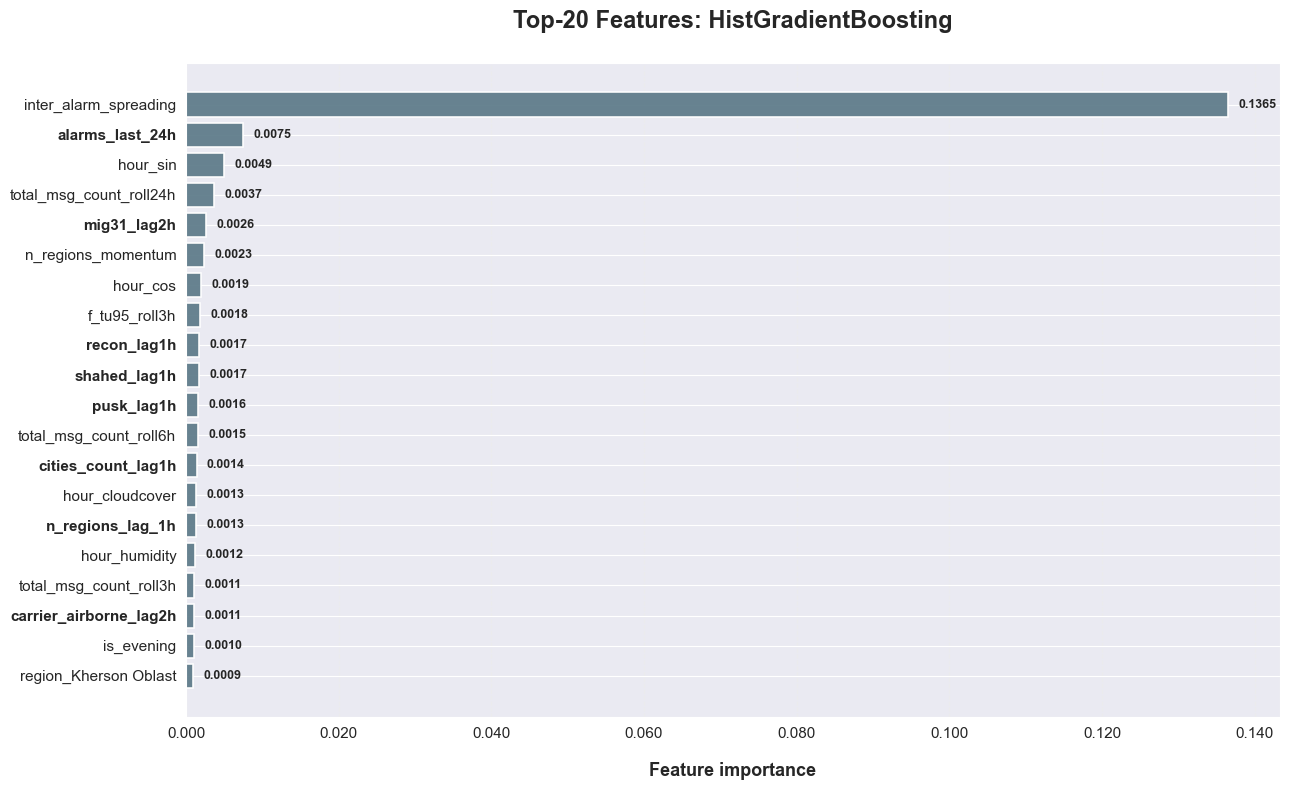

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
df_lgbm_imp = pd.read_csv('../models/_feature_importance_lightgbm.csv')
df_xgb_imp  = pd.read_csv('../models/feature_importance_xgboost.csv')
df_hgbm_imp = pd.read_csv('../models/feature_importance_histgbm.csv')
pal = {'LightGBM': '#B00020', 'XGBoost':  '#1A237E', 'HistGBM':  '#607D8B'}
def plot_top20_inline(importance_series, title, color, note):
    _fig, _ax = plt.subplots(figsize=(13, 8), facecolor='white')
    _bars = _ax.barh(importance_series.index, importance_series.values,
                     color=color, alpha=0.95, edgecolor='white', linewidth=1.2)
    for _bar, val in zip(_bars, importance_series.values):
        _ax.text(_bar.get_width() + max(importance_series.values) * 0.01,
                 _bar.get_y() + _bar.get_height() / 2, f'{val:.4f}',
                 ha='left', va='center', fontsize=9, fontweight='bold')
    for label in _ax.get_yticklabels():
        if 'lag' in label.get_text() or 'last_24h' in label.get_text():
            label.set_fontweight('bold')
    _ax.set_xlabel(note, fontsize=13, fontweight='bold', labelpad=15)
    _ax.set_title(title, fontsize=17, fontweight='bold', pad=25)
    _ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))
    _ax.tick_params(axis='both', labelsize=11)
    _ax.grid(axis='x', linestyle='--', color='#ececec', alpha=0.8)
    plt.tight_layout()
    plt.show()
lgbm_top20 = df_lgbm_imp.set_index('feature')['importance'].nlargest(20).sort_values()
xgb_top20  = df_xgb_imp.set_index('feature')['importance'].nlargest(20).sort_values()
hgbm_top20 = df_hgbm_imp.set_index('feature')['importance'].nlargest(20).sort_values()
plot_top20_inline(lgbm_top20, 'Top-20 Features: LightGBM', pal['LightGBM'], 'Feature importance')
plot_top20_inline(xgb_top20, 'Top-20 Features: XGBoost', pal['XGBoost'], 'Feature importance')
plot_top20_inline(hgbm_top20, 'Top-20 Features: HistGradientBoosting', pal['HistGBM'], 'Feature importance')

# LightGBM top 20 features
This figure shows the top 20 most important features for the **LightGBM model**. The dominant feature is alarms_last_24h, followed by hour_cos, and also the regional density features lag n_regions_lag_1h. Message counts (total_msg_count_roll3h) and specific threat indicators like f_tu95_roll3h and shahed_lag1h rank highly, suggesting that LightGBM is particularly effective at capturing the intensity of informational flow and specific weapon-type triggers as primary predictive signals.

# XGBoost top 20 features
This figure illustrates the top 20 most impactful features for the **XGBoost model**. inter_alarm_spreading emerges as the most influential feature, being much more impactful than the second feature alarm_lag_24h. XGBoost prioritizes how alarms spread between different areas as primary logic. The model shows a specialized focus on frontline dynamics: frontline_multi_alarm, syn_frontline_shahed, and is_frontline and on specific geographical regions: Kharkiv, Dnipropetrovsk, Poltava, Mykolaiv.

# HistGradientBoosting top 20 features
This figure displays the top 20 important features for the **HistGradientBoosting model**. Similar to XGBoost, this model identifies inter_alarm_spreading as the most impactful feature and the definitive lead predictor. Alarms_last_24h and hour_sin, hour_cos also remain as the core components. A unique aspect of the HistGBM model is its integration of threat-specific lags such as mig31_lag2h, shahed_lag1h, recon_lag1h, pusk_lag1h. This model is more sensitive to the meteorological features such as hour_cloudcover, hour_humidity, as these weather conditions are important for specific drone or missile operations. By balancing historical alert counts, specific aerial threat types and environmental conditions, HistGbm creates a highly predictive signature.